# Comparing Different Optimizers Across Different Strategies

Strategy: We know the nearest forecast of our park which we can use to devise good strategy
Simple Strategy: Sell the remaining quantity at or above limit price

In [4]:
import pandas as pd
from datetime import datetime, timedelta
import os
from strategy.BenchmarkStrategy import calculate_benchmark_strategy
import seaborn as sns
import matplotlib.pyplot as plt
from helper_funcs import generate_dates
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# load testing dates
dates = generate_dates("2024-09-17", "2024-10-16")
print(dates)

['2024-09-17', '2024-09-18', '2024-09-19', '2024-09-20', '2024-09-21', '2024-09-22', '2024-09-23', '2024-09-24', '2024-09-25', '2024-09-26', '2024-09-27', '2024-09-28', '2024-09-29', '2024-09-30', '2024-10-01', '2024-10-02', '2024-10-03', '2024-10-04', '2024-10-05', '2024-10-06', '2024-10-07', '2024-10-08', '2024-10-09', '2024-10-10', '2024-10-11', '2024-10-12', '2024-10-13', '2024-10-14', '2024-10-15', '2024-10-16']


## DF to Input The Results of Strategies and Benchmark

In [6]:
# Reinitializing the lists after reset - lamb is risk aversion and alpha is CVaR
lamb = [0.1, 0.25, 0.5]
alpha = [0.85, 0.90, 0.95]

# Creating the combinations
combinations = [(l, a) for l in lamb for a in alpha]

# Adding (0, 0.85) at the start
combinations.insert(0, (0, 0.85))


In [7]:
def process_strategy_results(combinations, dates, path):
    """
    Processes strategy results by computing revenues and comparing them to a benchmark.

    For each strategy in the given combinations and each date, this function:
    - Loads the corresponding schedule file (if it exists).
    - Calculates revenues from Day-Ahead (DA) and Intraday (ID) markets based on market 
      clearing prices (MCPs) and accepted bid volumes.
    - Computes a benchmark strategy where 90% of available energy is sold in the Day-Ahead 
      market at MCP_DA.
    - Calculates excess returns as the percentage difference between strategy revenue 
      and benchmark revenue.
    - Computes cumulative excess returns over time for each strategy.

    Parameters:
        combinations (list): List of strategy parameter tuples (e.g., (param1, param2)).
        dates (list): List of date strings to process (format assumed to match filenames).
        path (str): Base directory path where strategy schedule CSVs are stored.

    Returns:
        pd.DataFrame: A DataFrame with the following columns for each strategy and date:
            - strategy: Strategy identifier
            - date: Date of the schedule
            - schedule_key: Unique key for strategy/date
            - total_revenue: Total revenue from DA and ID markets
            - benchmark_revenue: Revenue from benchmark strategy
            - total_da_bids: Sum of DA bids in the strategy
            - total_da_benchmark_bids: Total DA bids used in the benchmark
            - total_volume_risk: Total intraday volume (deviation)
            - total_benchmark_volume_risk: Intraday volume in the benchmark
            - total_da_revenue: Revenue from DA market
            - total_id_revenue: Revenue from ID market
            - excess_returns: % return relative to benchmark
            - cumulative_excess_returns: Cumulative excess returns over time
    """
    results = []

    # Iterate over combinations
    for strategy in combinations:
        strategy_dir = os.path.join(path, f"{strategy[0]}_{strategy[1]}")

        for date in dates:
            try:
                # Define schedule paths dynamically
                schedule_path = os.path.join(strategy_dir, f"schedule_{date}.csv")
                
                # Check if the schedule file exists
                if os.path.exists(schedule_path):
                    schedule = pd.read_csv(schedule_path)
                else:
                    print(f"File not found: {schedule_path}")
                    continue

                # Calculate Intraday and Day-Ahead revenue
                id_revenue = schedule['MCP_ID'] * schedule['volume_risk']
                da_revenue = schedule['MCP_DA'] * schedule['DA_Bid']
                total_revenue = da_revenue + id_revenue
                total_revenue_sum = total_revenue.sum()
                # Calculate benchmark strategy revenue
                benchmark_strategy = calculate_benchmark_strategy(
                    schedule, date, da_sell_threshold=0.9
                )

                # Append results for this date and schedule type
                results.append({
                    'strategy'                   : f"{strategy[0]}_{strategy[1]}",
                    'date'                       : date,
                    'schedule_key'               : f"{strategy[0]}_{strategy[1]}",
                    'total_revenue'              : total_revenue_sum,
                    'benchmark_revenue'          : benchmark_strategy['total_revenue_benchmark'],
                    'total_da_bids'              : schedule['DA_Bid'].sum(),
                    'total_da_benchmark_bids'    : benchmark_strategy['total_da_benchmark_bids'],
                    'total_volume_risk'          : schedule['volume_risk'].sum(),
                    'total_benchmark_volume_risk': benchmark_strategy['total_benchmark_volume_risk'],
                    'total_da_revenue'           : da_revenue.sum(),
                    'total_id_revenue'           : id_revenue.sum()
                })
            except Exception as e:
                print(f"Error processing {strategy_dir} for date {date}: {e}")

    # Convert results to a DataFrame
    results_df = pd.DataFrame(results)

    # Ensure expected columns exist
    if not results_df.empty and 'strategy' in results_df.columns:
        # Sort by date and schedule type for consistency
        results_df.sort_values(by=['strategy', 'date', 'schedule_key'], inplace=True)

        # Calculate excess returns: percentage difference from benchmark revenue
        results_df['excess_returns'] = (
            (results_df['total_revenue'] - results_df['benchmark_revenue']) /
            results_df['benchmark_revenue'] * 100
        )

        # Calculate cumulative excess returns, starting from 0 for each strategy and schedule type
        results_df['cumulative_excess_returns'] = results_df.groupby(['strategy', 'schedule_key'])['excess_returns'].cumsum()

        # Reset index for clean display
        results_df.reset_index(drop=True, inplace=True)

    return results_df

## Comparison Plots

In [8]:
def plot_cumulative_excess_returns(strategy_df, optim):
    """
    Plot cumulative excess returns over time with consistent color mapping.
    
    Parameters:
        strategy_df (pd.DataFrame): Data containing strategy information.
        optim (str): Title suffix for the plot.
    """
    strategy_mapping = {
        "0_0.85": "risk neutral",
        "0.1_0.85": "CVaR, α=85%, λ=10%",
        "0.1_0.9": "CVaR, α=90%, λ=10%",
        "0.1_0.95": "CVaR, α=95%, λ=10%",
        "0.25_0.85": "CVaR, α=85%, λ=25%",
        "0.25_0.9": "CVaR, α=90%, λ=25%",
        "0.25_0.95": "CVaR, α=95%, λ=25%",
        "0.5_0.85": "CVaR, α=85%, λ=50%",
        "0.5_0.9": "CVaR, α=90%, λ=50%",
        "0.5_0.95": "CVaR, α=95%, λ=50%"
    }

    strategy_colors = {
        "risk neutral": "#a50026",
        "CVaR, α=85%, λ=10%": "#d73027",
        "CVaR, α=90%, λ=10%": "#f46d43",
        "CVaR, α=95%, λ=10%": "#fdae61",
        "CVaR, α=85%, λ=25%": "#fee08b",
        "CVaR, α=90%, λ=25%": "#d9ef8b",
        "CVaR, α=95%, λ=25%": "#a6d96a",
        "CVaR, α=85%, λ=50%": "#66bd63",
        "CVaR, α=90%, λ=50%": "#1a9850",
        "CVaR, α=95%, λ=50%": "#006837"
    }

    plt.figure(figsize=(14, 4))

    for strategy, group in strategy_df.groupby('strategy'):
        mapped_strategy = strategy_mapping.get(strategy, strategy)
        color = strategy_colors.get(mapped_strategy, "#000000")  # Default to black if not mapped
        plt.plot(group['date'], group['cumulative_excess_returns'], label=mapped_strategy, alpha=0.8, color=color)

    # plt.xlabel("Date", fontsize=14)
    plt.ylabel("Cumulative Excess Returns (%)", fontsize=14)
    plt.legend(title="Strategies", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.xticks(rotation=45)
    plt.grid(visible=True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('images/strategy/optim2/cumulative_returns_linechart.png')
    plt.show()


def plot_total_vs_benchmark_revenue(strategy_df, optim):
    """
    Plot total revenue vs benchmark revenue over time with consistent color mapping.
    
    Parameters:
        strategy_df (pd.DataFrame): Data containing strategy information.
        optim (str): Title suffix for the plot.
    """
    strategy_mapping = {
        "0_0.85": "risk neutral",
        "0.1_0.85": "CVaR, α=85%, λ=10%",
        "0.1_0.9": "CVaR, α=90%, λ=10%",
        "0.1_0.95": "CVaR, α=95%, λ=10%",
        "0.25_0.85": "CVaR, α=85%, λ=25%",
        "0.25_0.9": "CVaR, α=90%, λ=25%",
        "0.25_0.95": "CVaR, α=95%, λ=25%",
        "0.5_0.85": "CVaR, α=85%, λ=50%",
        "0.5_0.9": "CVaR, α=90%, λ=50%",
        "0.5_0.95": "CVaR, α=95%, λ=50%"
    }

    strategy_colors = {
        "risk neutral": "#a50026",
        "CVaR, α=85%, λ=10%": "#d73027",
        "CVaR, α=90%, λ=10%": "#f46d43",
        "CVaR, α=95%, λ=10%": "#fdae61",
        "CVaR, α=85%, λ=25%": "#fee08b",
        "CVaR, α=90%, λ=25%": "#d9ef8b",
        "CVaR, α=95%, λ=25%": "#a6d96a",
        "CVaR, α=85%, λ=50%": "#66bd63",
        "CVaR, α=90%, λ=50%": "#1a9850",
        "CVaR, α=95%, λ=50%": "#006837"
    }

    unique_dates = strategy_df['date'].drop_duplicates().sort_values()
    plt.figure(figsize=(14, 4))

    for strategy, group in strategy_df.groupby('strategy'):
        mapped_strategy = strategy_mapping.get(strategy, strategy)
        color = strategy_colors.get(mapped_strategy, "#000000")  # Default to black if not mapped
        group = group.sort_values('date')
        plt.plot(group['date'], group['total_revenue'], label=f"Total Revenue ({mapped_strategy})", alpha=0.8, color=color)

    benchmark_data = strategy_df.groupby('date')['benchmark_revenue'].mean().reindex(unique_dates)
    plt.plot(unique_dates, benchmark_data, linestyle='--', color='black', label="Benchmark Revenue", linewidth=2)

    # plt.xlabel("Date", fontsize=14)
    plt.ylabel("Revenue (EUR)", fontsize=14)
    plt.legend(title="Revenue", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.xticks(rotation=45)
    plt.grid(visible=True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_excess_returns(strategy_df, optim):
    """
    Plot excess returns over time as a bar plot with consistent color mapping.
    
    Parameters:
        strategy_df (pd.DataFrame): Data containing strategy information.
        optim (str): Title suffix for the plot.
    """
    strategy_mapping = {
        "0_0.85": "risk neutral",
        "0.1_0.85": "CVaR, α=85%, λ=10%",
        "0.1_0.9": "CVaR, α=90%, λ=10%",
        "0.1_0.95": "CVaR, α=95%, λ=10%",
        "0.25_0.85": "CVaR, α=85%, λ=25%",
        "0.25_0.9": "CVaR, α=90%, λ=25%",
        "0.25_0.95": "CVaR, α=95%, λ=25%",
        "0.5_0.85": "CVaR, α=85%, λ=50%",
        "0.5_0.9": "CVaR, α=90%, λ=50%",
        "0.5_0.95": "CVaR, α=95%, λ=50%"
    }

    strategy_colors = {
        "risk neutral": "#a50026",
        "CVaR, α=85%, λ=10%": "#d73027",
        "CVaR, α=90%, λ=10%": "#f46d43",
        "CVaR, α=95%, λ=10%": "#fdae61",
        "CVaR, α=85%, λ=25%": "#fee08b",
        "CVaR, α=90%, λ=25%": "#d9ef8b",
        "CVaR, α=95%, λ=25%": "#a6d96a",
        "CVaR, α=85%, λ=50%": "#66bd63",
        "CVaR, α=90%, λ=50%": "#1a9850",
        "CVaR, α=95%, λ=50%": "#006837"
    }

    plt.figure(figsize=(14, 4))

    for strategy, group in strategy_df.groupby('strategy'):
        mapped_strategy = strategy_mapping.get(strategy, strategy)
        color = strategy_colors.get(mapped_strategy, "#000000")  # Default to black if not mapped
        plt.bar(group['date'], group['excess_returns'], alpha=0.6, label=f"Excess Returns ({mapped_strategy})", color=color)

    # plt.xlabel("Date", fontsize=14)
    plt.ylabel("Excess Returns (%)", fontsize=14)
    plt.legend(title="Strategies", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.xticks(rotation=45)
    plt.grid(visible=True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('images/strategy/optim2/cumulative_returns_barchart.png')
    plt.show()



def plot_contribution_margins(bids_df, title_suffix):
    """
    Plot two bar charts: one for Day-Ahead Contribution Margin and one for Intraday Contribution Margin.

    Parameters:
        bids_df (pd.DataFrame): DataFrame containing bid information with columns:
            'date', 'strategy', 'total_da_revenue', 'total_da_bids', 'total_id_revenue', 'total_volume_risk'.
        title_suffix (str): Suffix for the plot title.
    """
    # Mapping from raw strategy names to readable names
    strategy_mapping = {
        "0_0.85": "risk neutral",
        "0.1_0.85": "CVaR, α=85%, λ=10%",
        "0.1_0.9": "CVaR, α=90%, λ=10%",
        "0.1_0.95": "CVaR, α=95%, λ=10%",
        "0.25_0.85": "CVaR, α=85%, λ=25%",
        "0.25_0.9": "CVaR, α=90%, λ=25%",
        "0.25_0.95": "CVaR, α=95%, λ=25%",
        "0.5_0.85": "CVaR, α=85%, λ=50%",
        "0.5_0.9": "CVaR, α=90%, λ=50%",
        "0.5_0.95": "CVaR, α=95%, λ=50%"
    }

    # Custom color palette for strategies
    strategy_colors = {
        "risk neutral": "#a50026",
        "CVaR, α=85%, λ=10%": "#d73027",
        "CVaR, α=90%, λ=10%": "#f46d43",
        "CVaR, α=95%, λ=10%": "#fdae61",
        "CVaR, α=85%, λ=25%": "#fee08b",
        "CVaR, α=90%, λ=25%": "#d9ef8b",
        "CVaR, α=95%, λ=25%": "#a6d96a",
        "CVaR, α=85%, λ=50%": "#66bd63",
        "CVaR, α=90%, λ=50%": "#1a9850",
        "CVaR, α=95%, λ=50%": "#006837"
    }

    # Filter the last 5 dates for plotting
    recent_dates = bids_df['date'].drop_duplicates().sort_values().iloc[15:20]
    filtered_data = bids_df[bids_df['date'].isin(recent_dates)].copy()

    # Map raw strategy names to readable names
    filtered_data['strategy'] = filtered_data['strategy'].map(strategy_mapping)

    # Validate that all strategies are present in the palette
    missing_strategies = set(filtered_data['strategy']) - set(strategy_colors.keys())
    if missing_strategies:
        raise ValueError(f"The following strategies are missing from the palette: {missing_strategies}")

    # Calculate adjusted contribution margins
    filtered_data['da_contribution_margin'] = filtered_data['total_da_revenue'] - (-2 * filtered_data['total_da_bids'])
    filtered_data['id_contribution_margin'] = filtered_data['total_id_revenue'] - (-2 * filtered_data['total_volume_risk'])

    # Melt data for Seaborn compatibility
    da_melted = filtered_data[['date', 'strategy', 'da_contribution_margin']].rename(
        columns={'da_contribution_margin': 'Contribution Margin'}
    )
    id_melted = filtered_data[['date', 'strategy', 'id_contribution_margin']].rename(
        columns={'id_contribution_margin': 'Contribution Margin'}
    )

    # Sort strategies to ensure "risk neutral" appears first
    sorted_strategies = ["risk neutral"] + [s for s in strategy_colors if s != "risk neutral"]
    da_melted['strategy'] = pd.Categorical(da_melted['strategy'], categories=sorted_strategies, ordered=True)
    id_melted['strategy'] = pd.Categorical(id_melted['strategy'], categories=sorted_strategies, ordered=True)

    # Set Seaborn style
    sns.set(style="whitegrid", palette="muted", font_scale=1.1)
    
    # Initialize figure and subplots
    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

    # Plot Day-Ahead Contribution Margin
    sns.barplot(
        data=da_melted,
        x='date',
        y='Contribution Margin',
        hue='strategy',
        ax=axes[0],
        palette=strategy_colors,
        dodge=True
    )
    axes[0].set_title(f"Day Ahead Contribution Margin ({title_suffix})", fontsize=12, weight='bold')
    axes[0].set_ylabel("Contribution Margin [EUR/day]", fontsize=10)
    axes[0].legend(title="Strategies", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
    axes[0].grid(visible=True, linestyle='--', alpha=0.7)

    # Plot Intraday Contribution Margin
    sns.barplot(
        data=id_melted,
        x='date',
        y='Contribution Margin',
        hue='strategy',
        ax=axes[1],
        palette=strategy_colors,
        dodge=True
    )
    axes[1].set_title(f"Intraday Contribution Margin ({title_suffix})", fontsize=12, weight='bold')
    axes[1].set_xlabel("Date", fontsize=10)
    axes[1].set_ylabel("Contribution Margin [EUR/day]", fontsize=10)
    axes[1].legend(title="Strategies", fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
    axes[1].grid(visible=True, linestyle='--', alpha=0.7)

    # Adjust layout
    plt.tight_layout()
    plt.show()

## Optimizer 2

### CLUSTER K = 5

In [9]:
path = f"strategy/optim2/gurobi/schedule/C5"
results_df = process_strategy_results(combinations, dates, path)

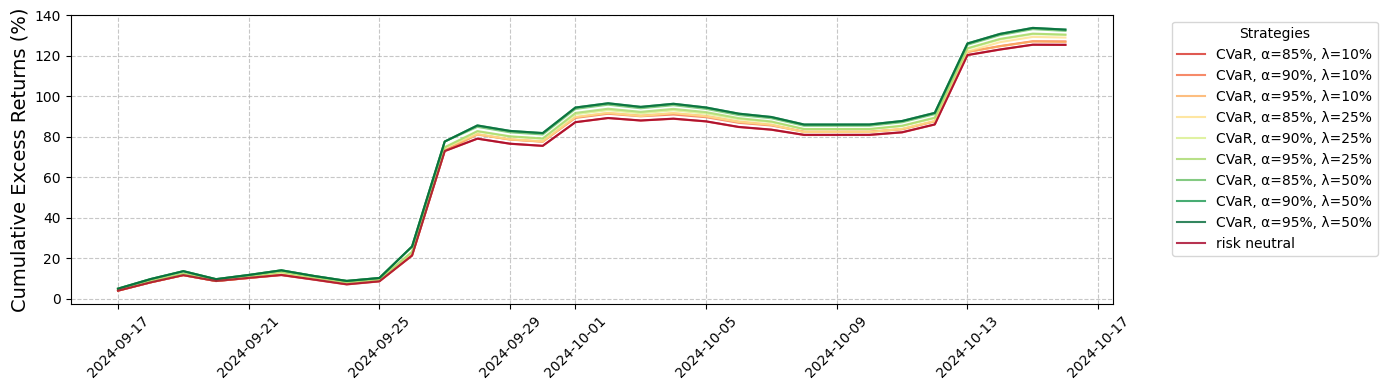

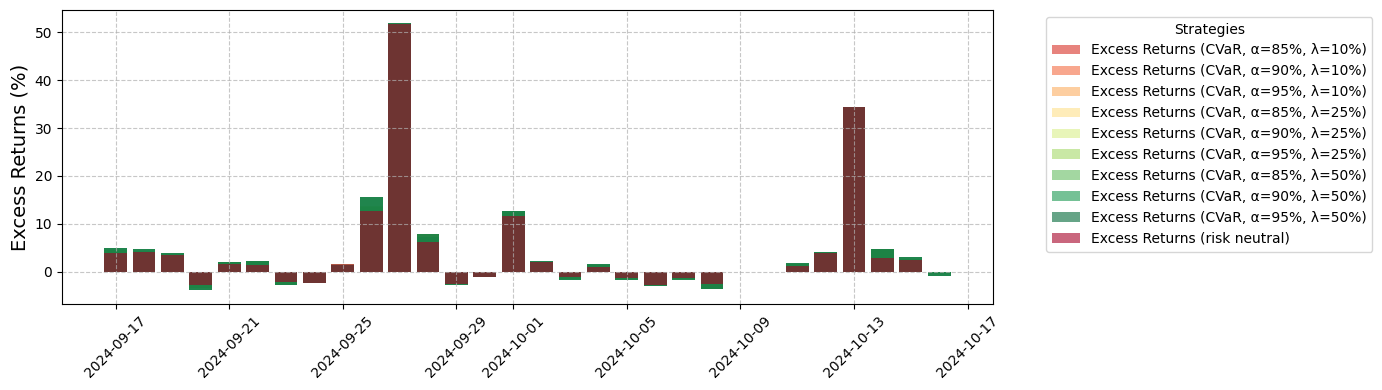

In [10]:
results_df['date'] = pd.to_datetime(results_df['date'])
plot_cumulative_excess_returns(results_df, optim="Optimizer 2")
# plot_total_vs_benchmark_revenue(results_df, optim="Optimizer 2")
plot_excess_returns(results_df, optim="Optimizer 2")
# plot_contribution_margins(results_df, "Optimal Bidding Strategies")

## K = 10 - our cluster we work on for thesis

In [15]:
path = f"strategy/optim2/gurobi/schedule/C10"
results_df = process_strategy_results(combinations, dates, path)

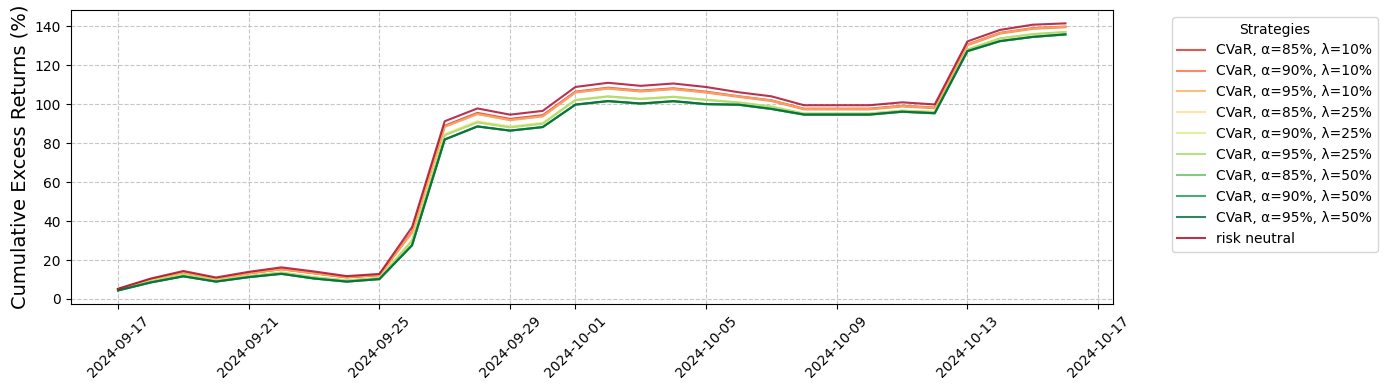

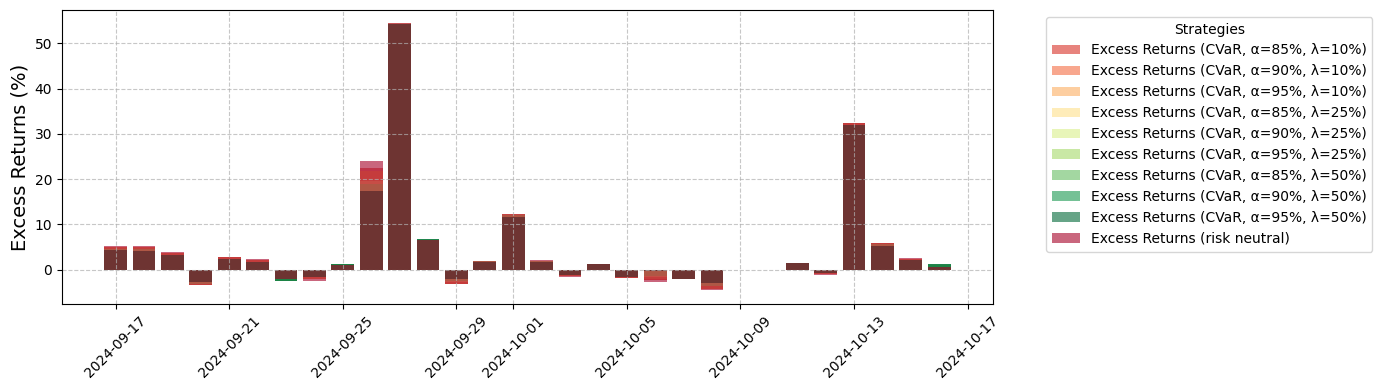

In [16]:
results_df['date'] = pd.to_datetime(results_df['date'])
plot_cumulative_excess_returns(results_df, optim="Optimizer 2")
# plot_total_vs_benchmark_revenue(results_df, optim="Optimizer 2")
plot_excess_returns(results_df, optim="Optimizer 2")
# plot_contribution_margins(results_df, "Optimal Bidding Strategies")

### K = 25

In [13]:
path = f"strategy/optim2/gurobi/schedule/C25"
results_df = process_strategy_results(combinations, dates, path)

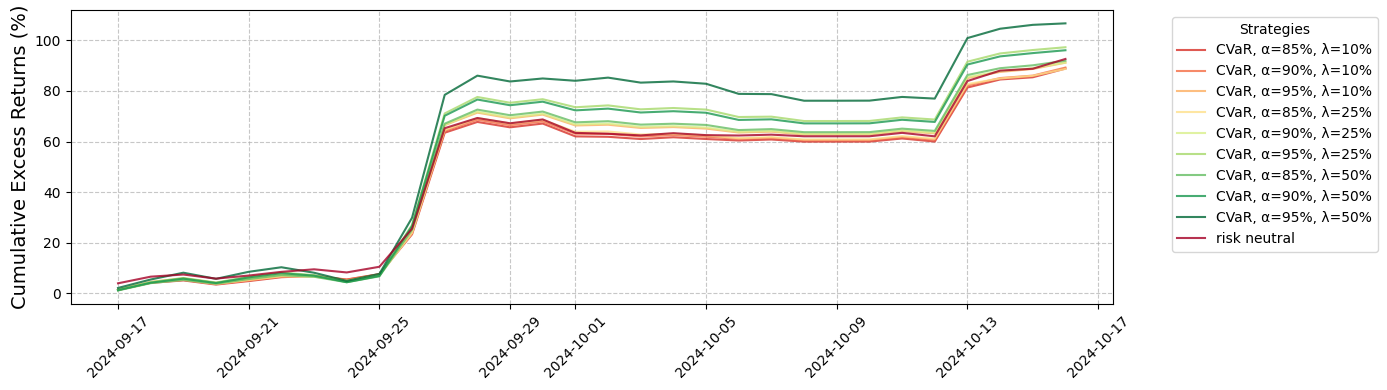

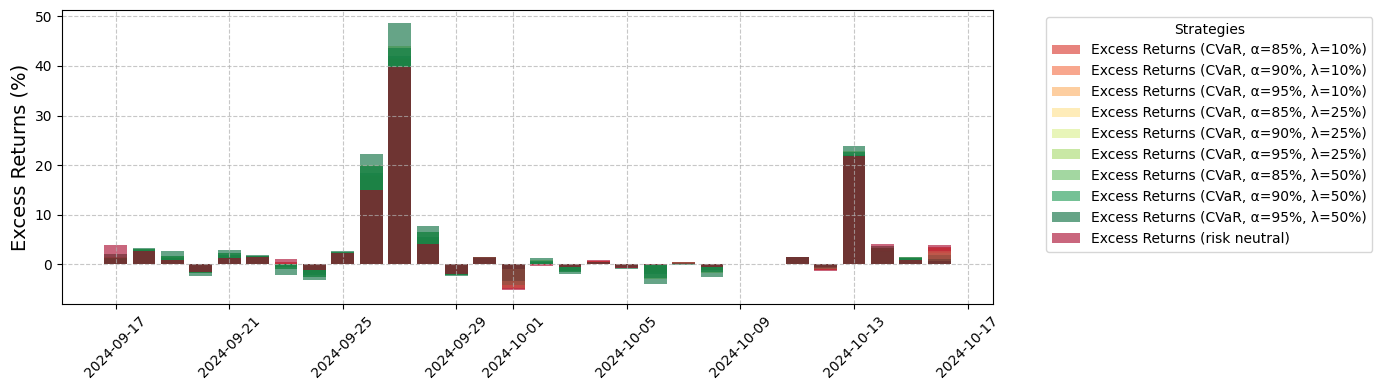

In [14]:
results_df['date'] = pd.to_datetime(results_df['date'])
plot_cumulative_excess_returns(results_df, optim="Optimizer 2")
# plot_total_vs_benchmark_revenue(results_df, optim="Optimizer 2")
plot_excess_returns(results_df, optim="Optimizer 2")
# plot_contribution_margins(results_df, "Optimal Bidding Strategies")